In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

### Reading the DataFrames

In [3]:
# Reading xlsx files
# Fires from 2011 to 2020
df_2011_2020 = pd.read_excel("../data/raw/Registos_Incendios_SGIF_2011_2020.xlsx")

# Fires from 2021 up to 2025 (most recent data)
df_2021_2025 = pd.read_excel("../data/raw/Registos_Incendios_SGIF_2021_2025.xlsx")

In [4]:
print(df_2011_2020.head())
print(f"\n Dataframe shape: \n {df_2011_2020.shape}")

  Codigo_SGIF  Codigo_ANEPC   Ano  Mes  Dia  Hora  AreaPov_ha  AreaMato_ha  \
0      DM2111           368  2011    1    1    17         0.0        0.010   
1      BL4112          1236  2011    1    9    22         0.0        0.000   
2      DM3111           820  2011    1   15    17         0.0        0.000   
3      BL2111          1977  2011    1   18    22         0.0        0.001   
4      DM2113          7930  2011    1   19    17         0.0        0.005   

   AreaAgric_ha  AreaTotal_ha  ...       ISI         DC       DMC       FFMC  \
0       0.00000       0.01000  ...  0.291930   4.092373  0.653638  54.525424   
1       0.00200       0.00200  ...  0.013831   1.835452  0.367371  32.001278   
2       0.00001       0.00001  ...  1.171990   9.658571  1.573768  74.889775   
3       0.00000       0.00100  ...  0.248910  12.477199  0.762519  51.102608   
4       0.00000       0.00500  ...  0.008092   3.968661  0.508191  32.290416   

        BUI  CodCausa     TipoCausa  \
0  0.934234

In [5]:
print(df_2021_2025.head())
print(f"\n Dataframe shape:\n {df_2021_2025.shape}")

  Codigo_SGIF   Codigo_ANEPC   Ano  Mes  Dia  Hora  AreaPov_ha  AreaMato_ha  \
0      BL3212  2021010001353  2021    1    5    15         0.0        0.000   
1      TM1213  2021170000717  2021    1    7    14         0.0        0.010   
2      BL1214  2021180001261  2021    1    7    18         0.0        0.680   
3      BL1215  2021180001268  2021    1    7    18         0.0        3.320   
4      TM2212  2021040000721  2021    1    7    18         0.0        0.003   

   AreaAgric_ha  AreaTotal_ha  ...       ISI        DC       DMC       FFMC  \
0        0.0123        0.0123  ...  0.697716  2.889986  0.776699  65.581411   
1        0.0000        0.0100  ...  1.579420  3.718020  1.333320  80.617788   
2        0.0000        0.6800  ...  1.817733  5.185042  1.513554  78.676647   
3        0.0000        3.3200  ...  1.500755  3.849406  1.232262  77.484526   
4        0.0000        0.0030  ...  1.615021  2.430952  1.077586  78.561693   

        BUI  CodCausa    TipoCausa  \
0  0.929128 

In [6]:
# Checking if both dataframes have same column names
df_2021_2025.columns.equals(df_2011_2020.columns)

True

In [7]:
print(f"""
    2011 to 2020 data types: \n {df_2011_2020.dtypes} \n \n
    2021 to 2025 data types: \n {df_2021_2025.dtypes}""")


    2011 to 2020 data types: 
 Codigo_SGIF                                str
Codigo_ANEPC                             int64
Ano                                      int64
Mes                                      int64
Dia                                      int64
Hora                                     int64
AreaPov_ha                             float64
AreaMato_ha                            float64
AreaAgric_ha                           float64
AreaTotal_ha                           float64
ClasseArea                                 str
DataHoraAlerta                  datetime64[us]
DataHora_PrimeiraIntervencao    datetime64[us]
DataHora_Extincao               datetime64[us]
Duracao_Horas                          float64
IncSup24horas                            int64
DTCCFR                                   int64
Distrito                                   str
Concelho                                   str
Freguesia                                  str
Local                       

### Concatenating both dataframes

In [8]:
# Concatenating both dataframes

fires = pd.concat([df_2011_2020, df_2021_2025])

print(f"""
    {fires.head()} \n
    Fires Shape: {fires.shape} \n
    Fires DTypes: {fires.dtypes}""")


      Codigo_SGIF  Codigo_ANEPC   Ano  Mes  Dia  Hora  AreaPov_ha  AreaMato_ha  \
0      DM2111           368  2011    1    1    17         0.0        0.010   
1      BL4112          1236  2011    1    9    22         0.0        0.000   
2      DM3111           820  2011    1   15    17         0.0        0.000   
3      BL2111          1977  2011    1   18    22         0.0        0.001   
4      DM2113          7930  2011    1   19    17         0.0        0.005   

   AreaAgric_ha  AreaTotal_ha  ...       ISI         DC       DMC       FFMC  \
0       0.00000       0.01000  ...  0.291930   4.092373  0.653638  54.525424   
1       0.00200       0.00200  ...  0.013831   1.835452  0.367371  32.001278   
2       0.00001       0.00001  ...  1.171990   9.658571  1.573768  74.889775   
3       0.00000       0.00100  ...  0.248910  12.477199  0.762519  51.102608   
4       0.00000       0.00500  ...  0.008092   3.968661  0.508191  32.290416   

        BUI  CodCausa     TipoCausa  \
0  0.9

### Filtering 2017-2025

In [120]:
# Filtering fires between 2017 to 2025
fires_2017_2025_raw  = fires[fires["Ano"].between(2017,2025)]
print(f"\n DataFrame Shape: {fires_2017_2025.shape}")
fires_2017_2025_raw.head()


 DataFrame Shape: (94337, 41)


,Codigo_SGIF,Codigo_ANEPC,Ano,Mes,Dia,Hora,AreaPov_ha,AreaMato_ha,AreaAgric_ha,AreaTotal_ha,...,ISI,DC,DMC,FFMC,BUI,CodCausa,TipoCausa,GrupoCausa,DescricaoCausa,FonteAlerta
123398,DM4171,2017030000006,2017,1,1,0,0.000,0.0100,0.0,0.0100,...,2.579540,26.225379,7.648318,85.187608,8.846614,60.0,Desconhecida,Indeterminadas,Indeterminadas,Populares
123399,BL3172,2017010000004,2017,1,1,0,0.000,0.0010,0.0,0.0010,...,2.652681,97.852669,8.396711,84.692546,13.827160,610.0,Desconhecida,Indeterminadas,Indeterminadas - Prova material,CCO
123400,RO2171,2017110000013,2017,1,1,0,0.000,0.0195,0.0,0.0195,...,2.640921,185.333806,6.343408,82.002968,11.686807,630.0,Desconhecida,Indeterminadas,Indeterminadas - Outras informações,112
123401,BL3171,2017010000007,2017,1,1,0,0.075,0.0000,0.0,0.0750,...,2.456941,26.463073,6.418945,83.327931,7.991686,6.0,Desconhecida,Indeterminadas,Indeterminadas,117
123402,DM4173,2017030000139,2017,1,1,12,0.000,0.0100,0.0,0.0100,...,2.659881,29.462939,7.738363,83.253734,9.342361,60.0,Desconhecida,Indeterminadas,Indeterminadas,117


# Basic Data Cleaning

In [121]:
fires_2017_2025 = fires_2017_2025_raw.copy()

In [122]:
fires_2017_2025.dtypes

Codigo_SGIF                             object
Codigo_ANEPC                             int64
Ano                                      int64
Mes                                      int64
Dia                                      int64
Hora                                     int64
AreaPov_ha                             float64
AreaMato_ha                            float64
AreaAgric_ha                           float64
AreaTotal_ha                           float64
ClasseArea                                 str
DataHoraAlerta                  datetime64[us]
DataHora_PrimeiraIntervencao    datetime64[us]
DataHora_Extincao               datetime64[us]
Duracao_Horas                          float64
IncSup24horas                            int64
DTCCFR                                 float64
Distrito                                   str
Concelho                                   str
Freguesia                                  str
Local                                   object
RNAP         

In [123]:
fires_2017_2025.columns

Index(['Codigo_SGIF', 'Codigo_ANEPC', 'Ano', 'Mes', 'Dia', 'Hora',
       'AreaPov_ha', 'AreaMato_ha', 'AreaAgric_ha', 'AreaTotal_ha',
       'ClasseArea', 'DataHoraAlerta', 'DataHora_PrimeiraIntervencao',
       'DataHora_Extincao', 'Duracao_Horas', 'IncSup24horas', 'DTCCFR',
       'Distrito', 'Concelho', 'Freguesia', 'Local', 'RNAP', 'RNMPF',
       'X_Militar', 'Y_Militar', 'Latitude', 'Longitude', 'X_ETRS89',
       'Y_ETRS89', 'DSR', 'FWI', 'ISI', 'DC', 'DMC', 'FFMC', 'BUI', 'CodCausa',
       'TipoCausa', 'GrupoCausa', 'DescricaoCausa', 'FonteAlerta'],
      dtype='str')

In [124]:
fires_2017_2025['Distrito'].unique()

<StringArray>
[           'Braga',           'Aveiro',           'Lisboa',
            'Porto',        'Vila Real',            'Viseu',
           'Guarda', 'Viana do Castelo',          'Coimbra',
          'Setúbal',           'Leiria',   'Castelo Branco',
         'Bragança',       'Portalegre',         'Santarém',
             'Faro',             'Beja',            'Évora',
 'Viana Do Castelo',                nan]
Length: 20, dtype: str

In [125]:
# Since there is 'Viana do Castelo' and 'Viana Do Castelo' , let's make them equal
 

fires_2017_2025['Distrito'] = fires_2017_2025['Distrito'].replace({
    "Viana Do Castelo": "Viana do Castelo"})

In [126]:
fires_2017_2025.isna().sum()

Codigo_SGIF                         0
Codigo_ANEPC                        0
Ano                                 0
Mes                                 0
Dia                                 0
Hora                                0
AreaPov_ha                          0
AreaMato_ha                         0
AreaAgric_ha                        0
AreaTotal_ha                        0
ClasseArea                          0
DataHoraAlerta                      0
DataHora_PrimeiraIntervencao      378
DataHora_Extincao                 235
Duracao_Horas                     235
IncSup24horas                       0
DTCCFR                              1
Distrito                            1
Concelho                            1
Freguesia                           1
Local                               0
RNAP                            90758
RNMPF                           90030
X_Militar                           0
Y_Militar                           0
Latitude                            0
Longitude   

In [127]:
fires_2017_2025[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,94337.000000,94337.000000
mean,40.494475,-8.246405
std,1.216889,0.550693
min,28.899398,-9.617032
25%,39.590910,-8.579847
50%,41.036189,-8.333947
75%,41.362222,-7.930065
max,48.049938,-6.119167


In [128]:
# Latitude min = 28.90
# Latitude max = 48.05
# These coordinates are outside of Portugal, let's find out where they are

invalid_coords = fires_2017_2025[
    ~fires_2017_2025["Latitude"].between(36.9, 42.2) |
    ~fires_2017_2025["Longitude"].between(-9.6, -6.1)
]

invalid_coords.shape

(3, 41)

In [129]:
# Will try to get these coordinates back from X_ETRS89 e Y_ETRS89 columns
invalid_coords[[
    "Codigo_SGIF",
    "Ano",
    "Distrito",
    "Concelho",
    "Latitude",
    "Longitude"
]]

,Codigo_SGIF,Ano,Distrito,Concelho,Latitude,Longitude
136732,BL3171697,2017,Aveiro,Castelo de Paiva,48.049938,-8.244897
152591,RO2182086,2018,Lisboa,Mafra,39.033538,-9.617032
5807,RO121499,2021,Santarém,Benavente,28.899398,-8.849402


In [130]:
print((fires_2017_2025["AreaTotal_ha"] < 0).sum())
print((fires_2017_2025["AreaPov_ha"] < 0).sum())
print((fires_2017_2025["AreaMato_ha"] < 0).sum())
print((fires_2017_2025["AreaAgric_ha"] < 0).sum())

0
0
0
0


In [131]:
# Checking if area sum is equal to the 3 area columns
area_sum = (
    fires_2017_2025["AreaPov_ha"]
    + fires_2017_2025["AreaMato_ha"]
    + fires_2017_2025["AreaAgric_ha"]
)

np.isclose(
    fires_2017_2025["AreaTotal_ha"],
    area_sum
).sum()

np.int64(94337)

In [132]:
fires_2017_2025["Duracao_Horas"].describe()

count    94102.000000
mean         1.569098
std          8.401042
min          0.000000
25%          0.466667
50%          0.783333
75%          1.400000
max       1674.600000
Name: Duracao_Horas, dtype: float64

In [133]:
# 1674 hours corresponds to 70 days, let's see if it's correct

fires_2017_2025.nlargest(10, "Duracao_Horas")[
    [
        "Codigo_SGIF",
        "DataHoraAlerta",
        "DataHora_Extincao",
        "Duracao_Horas",
        "Distrito",
        "Concelho",
        "AreaTotal_ha"
    ]
]

,Codigo_SGIF,DataHoraAlerta,DataHora_Extincao,Duracao_Horas,Distrito,Concelho,AreaTotal_ha
31350,20241151939,2024-09-16 15:53:00,2024-11-25 10:29:00,1674.600000,Porto,Baião,5944.783524
15634,2022_05_0022298,2022-08-06 03:18:00,2022-09-02 21:00:00,665.700000,Castelo Branco,Covilhã,24333.237905
15210,2022_13_0134336,2022-07-31 14:25:00,2022-08-25 10:41:00,596.266667,Porto,Amarante,134.271188
37416,20251056789,2025-08-09 16:21:00,2025-08-24 09:51:00,353.500000,Guarda,Trancoso,46917.088936
37744,20251075979,2025-08-13 05:08:00,2025-08-25 20:01:00,302.883333,Coimbra,Arganil,65478.286936
2494,BI22196,2021-05-28 12:06:00,2021-06-08 01:57:00,253.850000,Castelo Branco,Vila Velha de Ródão,0.000200
4025,BI221170,2021-07-13 18:41:00,2021-07-24 08:32:00,253.850000,Castelo Branco,Sertã,0.000100
4420,BI221188,2021-07-21 12:47:00,2021-08-01 02:38:00,253.850000,Castelo Branco,Castelo Branco,0.000100
4456,BI221191,2021-07-22 06:03:00,2021-08-01 19:54:00,253.850000,Castelo Branco,Vila Velha de Ródão,0.000100
4506,BI221198,2021-07-23 11:10:00,2021-08-03 01:01:00,253.850000,Castelo Branco,Castelo Branco,0.000100


A lot of fires with 253 hours is definitely suspicious but the duration of the ocurrence will not be a feature in the dataset, so there isn't much to worry about right now.

In [134]:
(fires_2017_2025["Duracao_Horas"] == 0).sum()

np.int64(21)

In [135]:
fires_2017_2025[fires_2017_2025["Distrito"].isna()][
    ["Codigo_SGIF", "Latitude", "Longitude", "Concelho", "Freguesia"]
]

,Codigo_SGIF,Latitude,Longitude,Concelho,Freguesia
31919,20241176561,38.677502,-9.207873,NaN,NaN


In [136]:
(fires_2017_2025["DataHora_PrimeiraIntervencao"] <
 fires_2017_2025["DataHoraAlerta"]).sum()

np.int64(0)

In [137]:
(fires_2017_2025["DataHora_Extincao"] <
 fires_2017_2025["DataHora_PrimeiraIntervencao"]).sum()

np.int64(1267)

In [138]:
invalid_time_order = fires_2017_2025[
    fires_2017_2025["DataHora_Extincao"]
    < fires_2017_2025["DataHora_PrimeiraIntervencao"]
]

invalid_time_order[
    [
        "Codigo_SGIF",
        "DataHoraAlerta",
        "DataHora_PrimeiraIntervencao",
        "DataHora_Extincao",
        "Duracao_Horas"
    ]
].head(10)

,Codigo_SGIF,DataHoraAlerta,DataHora_PrimeiraIntervencao,DataHora_Extincao,Duracao_Horas
123427,BL1178,2017-01-02 15:10:00,2017-01-02 15:25:00,2017-01-02 15:16:00,0.100000
123568,BL11755,2017-01-14 16:06:00,2017-01-14 16:30:00,2017-01-14 16:11:00,0.083333
123572,BL21722,2017-01-14 17:54:00,2017-01-14 18:04:00,2017-01-14 18:00:00,0.100000
123618,BL31747,2017-01-16 16:14:00,2017-01-16 16:30:00,2017-01-16 16:25:00,0.183333
123625,BL11768,2017-01-16 19:13:00,2017-01-16 19:25:00,2017-01-16 19:19:00,0.100000
123650,BL11778,2017-01-17 17:35:00,2017-01-17 18:04:00,2017-01-17 18:01:00,0.433333
123814,BL31778,2017-01-20 00:11:00,2017-01-20 00:30:00,2017-01-20 00:17:00,0.100000
123916,DM317232,2017-01-21 17:11:00,2017-01-21 17:57:00,2017-01-21 17:56:00,0.750000
123991,BL31799,2017-01-22 23:50:00,2017-01-23 00:02:00,2017-01-22 23:56:00,0.100000
124027,DM317271,2017-01-23 16:34:00,2017-01-23 17:05:00,2017-01-23 17:01:00,0.450000


In [139]:
(
    fires_2017_2025["DataHora_Extincao"]
    < fires_2017_2025["DataHoraAlerta"]
).sum()

np.int64(0)

In [140]:
(fires_2017_2025["Ano"] != fires_2017_2025["DataHoraAlerta"].dt.year).sum()

np.int64(0)

In [141]:
print((fires_2017_2025["Mes"] != fires_2017_2025["DataHoraAlerta"].dt.month).sum())

print((fires_2017_2025["Dia"] != fires_2017_2025["DataHoraAlerta"].dt.day).sum())

0
0


In [142]:
calculated_duration = (
    fires_2017_2025["DataHora_Extincao"]
    - fires_2017_2025["DataHoraAlerta"]
).dt.total_seconds() / 3600

In [143]:
valid_duration = (
    fires_2017_2025["Duracao_Horas"].notna()
    & calculated_duration.notna()
)

np.isclose(
    fires_2017_2025.loc[valid_duration, "Duracao_Horas"],
    calculated_duration[valid_duration]
).sum()

np.int64(94102)

In [144]:
valid_duration.sum()

np.int64(94102)

**Data quality note**: 1,267 records contain a first-intervention timestamp later than the extinction timestamp. 

Since alert and extinction timestamps remain chronologically consistent and first-intervention time is not required for wildfire risk modelling, these records were retained and the inconsistency was documented.

# Exploring the new DataFrame 

## Yearly Analysis

In [145]:
fires_2017_2025.isna().sum()

Codigo_SGIF                         0
Codigo_ANEPC                        0
Ano                                 0
Mes                                 0
Dia                                 0
Hora                                0
AreaPov_ha                          0
AreaMato_ha                         0
AreaAgric_ha                        0
AreaTotal_ha                        0
ClasseArea                          0
DataHoraAlerta                      0
DataHora_PrimeiraIntervencao      378
DataHora_Extincao                 235
Duracao_Horas                     235
IncSup24horas                       0
DTCCFR                              1
Distrito                            1
Concelho                            1
Freguesia                           1
Local                               0
RNAP                            90758
RNMPF                           90030
X_Militar                           0
Y_Militar                           0
Latitude                            0
Longitude   

In [146]:
# Checking for any duplicated values in the ID ("Codigo_SGIF") column
fires_2017_2025["Codigo_SGIF"].duplicated().sum()

np.int64(0)

2017 is a very atypical year. There was a huge fire in this year - Pedrógão Grande - but this value (210006) needs more research.
Albeit was a massive event, does it explain more than two times as many fires registered than the rest of the years? 

In [147]:
# Finding out how many fires per year
total_ocurrences = fires_2017_2025["Ano"].value_counts().sort_index()
total_ocurrences

Ano
2017    21006
2018    12274
2019    10832
2020     9619
2021     8186
2022    10390
2023     7523
2024     6255
2025     8252
Name: count, dtype: int64

#### Total Burned Area

When it comes to **area burned**, it's very interesting as well. 

There are ocurrences with 0 ha burned but there is a massive difference between the mean (13.51) and the median (0.05).

This means we have a **right-skewed distribution**: There are a small number of fires that had an enormous area burned.


In [148]:
fires_2017_2025["AreaTotal_ha"].describe()

count    94337.000000
mean        13.516066
std        466.070072
min          0.000000
25%          0.010000
50%          0.058000
75%          0.450000
max      65478.286936
Name: AreaTotal_ha, dtype: float64

In [149]:
# Checking how many fires with 0 burned area exist in the dataframe
(fires_2017_2025["AreaTotal_ha"] == 0).sum()

np.int64(227)

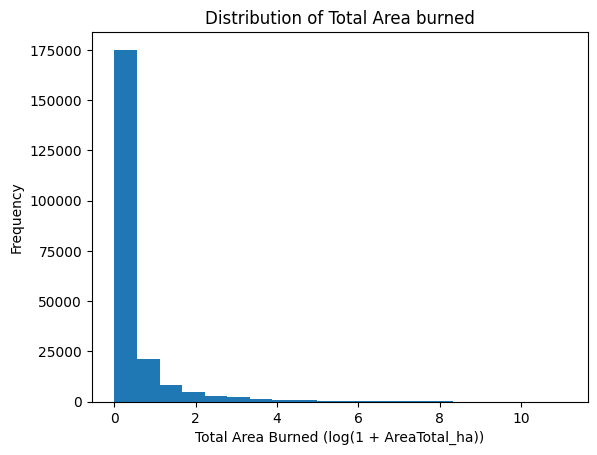

In [150]:
# Putting everything in the same scale with log since there are fires with 0 burned Area
plt.hist(np.log1p(fires["AreaTotal_ha"]), bins=20)

plt.title("Distribution of Total Area burned")

plt.xlabel("Total Area Burned (log(1 + AreaTotal_ha))")
plt.ylabel("Frequency")

plt.show()


#### Total Burned Area per Year

We've seen that 2017 had the most ocurrences so far (21006) and it also has the most burned area (539921 ha).

What's interesting is 2025. It has 8252 ocurrences, being the #5th year with most ocurrences, but it's #2nd in burned area, with 270695 ha burned.

In [151]:
total_area_burned_yearly = (
    fires_2017_2025.groupby(by="Ano")["AreaTotal_ha"]
    .agg(['mean','median','sum'])
    .round(2)
    .reset_index())
print(total_area_burned_yearly)

    Ano   mean  median        sum
0  2017  25.70    0.08  539921.00
1  2018   3.63    0.05   44577.50
2  2019   3.89    0.05   42083.92
3  2020   6.98    0.05   67169.93
4  2021   3.46    0.07   28360.01
5  2022  10.60    0.06  110097.06
6  2023   4.59    0.05   34509.21
7  2024  22.01    0.05  137651.42
8  2025  32.80    0.06  270695.11


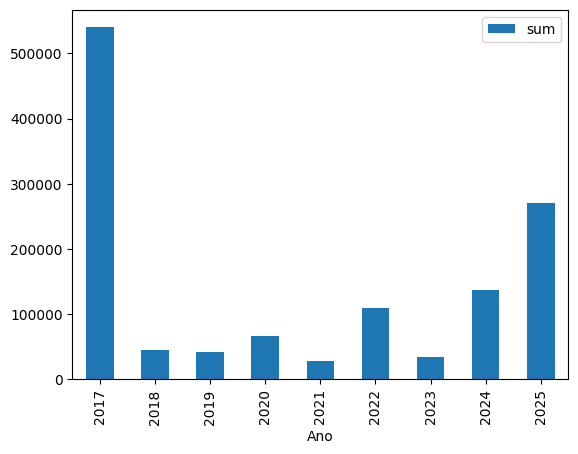

In [152]:
total_area_burned_yearly.plot(x='Ano',
                              y='sum',
                              kind='bar')

plt.show()

###  Exploring Fires from 2017 and 2025

In [153]:
top_10_fires = fires_2017_2025.nlargest(10, 'AreaTotal_ha',keep='all')
top_10_fires = top_10_fires[["Codigo_SGIF",
                             "Distrito",
                             "Concelho",
                             "AreaTotal_ha",
                             "Ano"]]
top_10_fires

,Codigo_SGIF,Distrito,Concelho,AreaTotal_ha,Ano
37744,20251075979,Coimbra,Arganil,65478.286936,2025
142090,BL2171045,Coimbra,Lousã,53618.811555,2017
37416,20251056789,Guarda,Trancoso,46917.088936,2025
142139,BL2171054,Coimbra,Arganil,37958.503115,2017
132550,BI2173957,Castelo Branco,Sertã,33639.680000,2017
142127,BI2174250,Castelo Branco,Sertã,33192.611000,2017
130108,BL4171577,Leiria,Pedrógão Grande,30358.840000,2017
150850,AG118728,Faro,Monchique,26763.825501,2018
15634,2022_05_0022298,Castelo Branco,Covilhã,24333.237905,2022
134984,BL4171971,Leiria,Alvaiázere,22824.488000,2017


In [154]:
# Calculating what percentage of yearly burned area was caused by fires with > 100 ha
 # Setting 'Ano' as the index so the indices match
total_by_year = total_area_burned_yearly.set_index("Ano")["sum"]

fires_over_100 = fires_2017_2025[fires_2017_2025["AreaTotal_ha"] > 100]
fires_over_100_by_year = fires_over_100.groupby("Ano")["AreaTotal_ha"].sum()

perc_fires_over_100 = (fires_over_100_by_year / total_by_year * 100).round(2)
print(perc_fires_over_100)

Ano
2017    93.67
2018    76.66
2019    64.79
2020    82.57
2021    53.09
2022    84.50
2023    68.73
2024    92.41
2025    95.64
dtype: float64


In [155]:
f_o_100group = fires_over_100.groupby("Ano")["AreaTotal_ha"].agg(['median', 'mean', 'sum', 'count'])
f_o_100group

,median,mean,sum,count
Ano,,,,
2017,295.427000,1873.123947,505743.465611,270
2018,250.000000,1366.855032,34171.375795,25
2019,195.743250,439.761891,27265.237224,62
2020,259.749250,840.365941,55464.152075,66
2021,193.000000,485.644203,15054.970281,31
2022,266.059292,930.306351,93030.635135,100
2023,197.256972,624.143631,23717.457984,38
2024,396.808124,1551.189697,127197.555171,82
2025,391.424563,2563.283817,258891.665538,101


In [156]:
perc_tot_ocurr_over_100 = (f_o_100group['count'] / total_ocurrences * 100)
perc_tot_ocurr_over_100

Ano
2017    1.285347
2018    0.203683
2019    0.572378
2020    0.686142
2021    0.378695
2022    0.962464
2023    0.505118
2024    1.310951
2025    1.223946
Name: count, dtype: float64

Now we can do some analysis: 

- 2017 had the **most total burned area**: 539 921ha
- 2025 saw 270 695 ha burned.

But 2025 had a bigger area burned, on average, per ocurrence:
- 2017: 25.7
- 2025: 32.8 ha 
 
The median, in both years, was low:
- 2017: 0.08 ha
- 2025: 0.06 ha

This shows that both years were dominated by small ocurrences while a small number of huge fires pull the mean up.

The percentage of burned area from fires with > 100 ha implies this:
- 2017: 93.67%
- 2025: 95.64%

In 2017, fires larger than 100 ha represented only about 1.29% of all occurrences, but accounted for approximately 93.7% of the total burned area. Similarly, in 2025, large fires represented around 1.2% of occurrences, while explaining more than 95% of the total burned area.

These results indicate that wildfire occurrence and wildfire severity are very different phenomena. Most recorded fires are small, while a small number of large events are responsible for the majority of the environmental impact.

#### Creating Classes for Burned Area

In [157]:
bins = [-0.001, 0, 0.1 , 1, 10, 100, 1000, np.inf]

lab = ['0 ha',
       '0 to 0.1 ha',
       '0.1 to 1 ha',
       '1 to 10 ha',
       '10 to 100 ha',
       '100 to 1000 ha',
       '>1000 ha']

fires_2017_2025['BurnedAreaCat'] = pd.cut(fires_2017_2025['AreaTotal_ha'],
                                          bins = bins,
                                          labels = lab,
                                          include_lowest=True)

fires_2017_2025['BurnedAreaCat'].value_counts().sort_index()

BurnedAreaCat
0 ha                227
0 to 0.1 ha       55327
0.1 to 1 ha       24527
1 to 10 ha        10561
10 to 100 ha       2920
100 to 1000 ha      618
>1000 ha            157
Name: count, dtype: int64

## Monthly Analysis

### Monthly Ocurrences

In [158]:
monthly_fires = fires_2017_2025.groupby('Mes').size()
monthly_fires

Mes
1      2520
2      4607
3      5544
4      6280
5      8068
6      8629
7     15862
8     19116
9     12517
10     8834
11     1616
12      744
dtype: int64

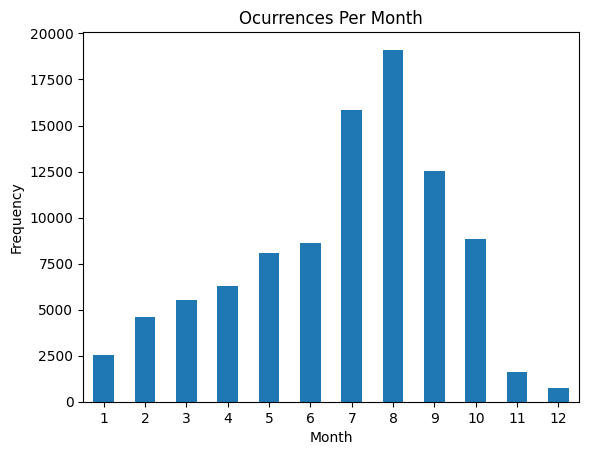

In [159]:
monthly_fires.plot(kind='bar')

plt.xticks(rotation=0)
plt.title('Ocurrences Per Month')

plt.xlabel('Month')
plt.ylabel('Frequency')

plt.show()

### Monthly Burned Area (Sum from 2017 to 2025)

In [160]:
total_monthly_burned = (
    fires_2017_2025.groupby('Mes')['AreaTotal_ha']
    .agg(['sum','mean','median']))

total_monthly_burned

,sum,mean,median
Mes,,,
1,11275.230596,4.474298,0.19295
2,11051.585093,2.398868,0.18500
3,19965.674846,3.601312,0.20000
4,14331.592888,2.282101,0.12310
5,7058.488667,0.874875,0.05000
6,70580.389079,8.179440,0.04510
7,196726.601590,12.402383,0.05000
8,441042.862686,23.071922,0.05000
9,199581.508113,15.944836,0.05000


In [161]:
# Seeing which months have fires over > 100ha

fires_over_100.groupby('Mes').size()

Mes
1      18
2      12
3      29
4      16
5       6
6      40
7     157
8     224
9     147
10    124
11      2
dtype: int64

The monthly analysis shows a clear seasonal pattern in wildfire activity. The number of recorded occurrences starts to increase from May, reaches its highest level in August, and remains relatively high until October.

However, the number of fires and their severity do not follow exactly the same pattern. For example, May recorded 8,068 occurrences but only around 7,058 hectares burned, while October had a similar number of occurrences, 8,834, but more than 300,000 hectares burned.

August stands out as the month with both the highest number of occurrences and the largest total burned area, with 19,116 recorded fires and approximately 441,043 hectares burned.

Large fires above 100 hectares are particularly concentrated between July and October, with August recording the highest number. This suggests that May may represent the beginning of the high-occurrence season, while the most severe wildfire activity is concentrated mainly between June and October.

## Geographical Analysis

In [162]:
# Which district has the most ocurrences? 

fires_2017_2025.groupby("Distrito").size().sort_values(ascending=False)



Distrito
Porto               20208
Braga                9299
Aveiro               7040
Viseu                6750
Viana do Castelo     6483
Vila Real            6274
Lisboa               6004
Santarém             5374
Setúbal              3406
Leiria               3305
Castelo Branco       3077
Bragança             3031
Coimbra              2766
Faro                 2576
Guarda               2568
Beja                 2389
Portalegre           1933
Évora                1853
dtype: int64

In [163]:
fires_2017_2025.groupby('Distrito')['AreaTotal_ha'].agg(['sum','mean','median'])

,sum,mean,median
Distrito,,,
Aveiro,51066.879026,7.253818,0.0380
Beja,22539.952122,9.434890,0.2171
Braga,49027.811489,5.272375,0.1300
Bragança,71272.667612,23.514572,0.4000
Castelo Branco,177131.154144,57.566186,0.0600
Coimbra,217513.352364,78.638233,0.0300
Faro,45281.559760,17.578245,0.0356
Guarda,185199.332067,72.118120,0.2500
Leiria,89660.175164,27.128646,0.0400


In [165]:
fires_over_100.groupby('Distrito').size().sort_values(ascending=False)

Distrito
Vila Real           105
Guarda               83
Viseu                82
Braga                75
Bragança             69
Viana do Castelo     65
Porto                53
Castelo Branco       47
Aveiro               29
Santarém             27
Beja                 26
Coimbra              26
Leiria               21
Portalegre           20
Faro                 18
Évora                14
Lisboa                9
Setúbal               6
dtype: int64

Porto records the highest number of occurrences, but districts such as Coimbra, Guarda and Castelo Branco present larger total burned areas and higher average burned area per fire. 

This indicates that regions with the most frequent fire occurrences are not necessarily the regions experiencing the most destructive fires.

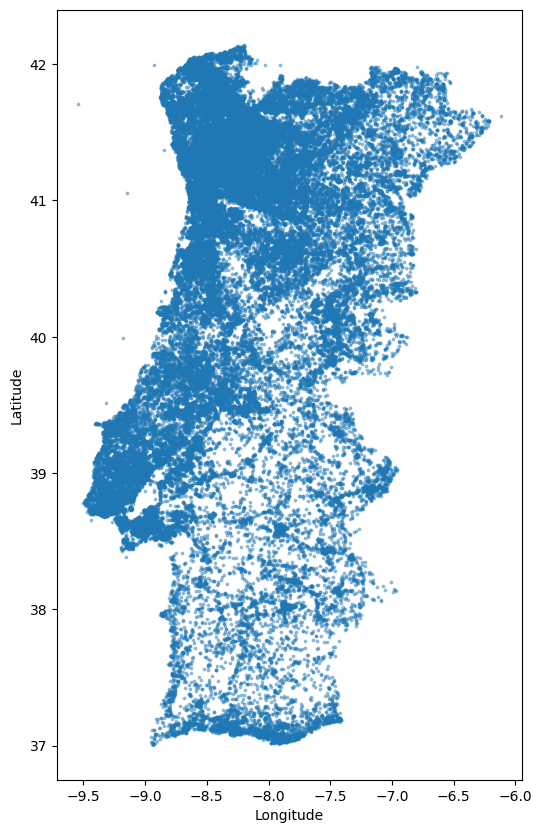

In [200]:
fires_valid_coords = fires_2017_2025[
    fires_2017_2025['Latitude'].between(36.9, 42.2) &
    fires_2017_2025['Longitude'].between(-9.6, -6.1)
]

fires_valid_coords.plot.scatter(
    x='Longitude',
    y='Latitude',
    s=3,
    alpha=0.4,
    figsize=(6,10)
    )

plt.show()

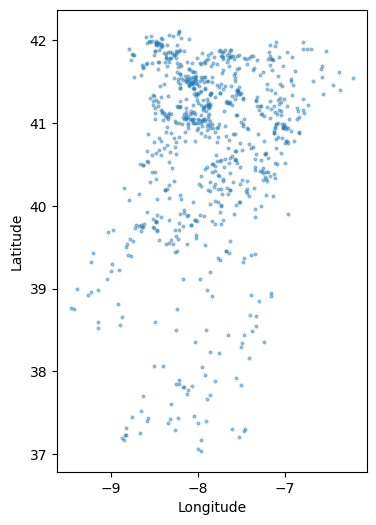

In [207]:
fires_over_100.plot.scatter(
    x='Longitude',
    y='Latitude',
    s=4,
    alpha=0.4,
    figsize=(4,6)
)
plt.show()

Since there are fires in the Atlantic Ocean, let's go from using simple functions like .between from pandas and move to the GeoPandas library.

The map of Portugal will be downloaded from **Carta Administrativa Oficial de Portugal**, accessible through: https://www.dgterritorio.gov.pt/atividades/cartografia/cartografia-tematica/caop

In [212]:
gpd.list_layers("../data/raw/CAOP_Continente_2025-gpkg/Continente_CAOP2025.gpkg")

,name,geometry_type
0,cont_areas_administrativas,Polygon
1,cont_distritos,MultiPolygon
2,cont_freguesias,MultiPolygon
3,cont_municipios,MultiPolygon
4,cont_nuts1,MultiPolygon
5,cont_nuts2,MultiPolygon
6,cont_nuts3,MultiPolygon
7,cont_trocos,LineString
8,layer_styles,NaN
9,inf_fonte_troco,NaN
